<a href="https://colab.research.google.com/github/polinachetaykina/text-ranking-stackoverflow/blob/main/texts_ranks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В этом ноутбуке мы будем сравнивать классические методы ранжирования текстов на задаче поиска похожих вопросов на StackOverflow:

1. Word2Vec (усреднение эмбеддингов слов) — показывает, насколько хороши предобученные вектора

2. TF-IDF + косинусная близость — классический метод из информационного поиска

3. BM25 — улучшенная версия TF-IDF, учитывающая длину документов

Это создаст базовый уровень (baseline), с которым мы потом будем сравнивать нейросетевые методы (SBERT).

Начнём с установки необходимых библиотек

In [ ]:
!pip install -q gensim scikit-learn nltk sentence-transformers torch transformers tqdm matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import re
import math
from tqdm.notebook import tqdm
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer

Скачиваем предобученные эмбеддинги StackOverflow (200-мерные вектора)

Эти эмбеддинги обучены на миллионах постов StackOverflow

In [ ]:
!wget https://zenodo.org/record/1199620/files/SO_vectors_200.bin?download=1

--2026-04-29 16:55:54--  https://zenodo.org/record/1199620/files/SO_vectors_200.bin?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.184.98.114, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/1199620/files/SO_vectors_200.bin [following]
--2026-04-29 16:55:55--  https://zenodo.org/records/1199620/files/SO_vectors_200.bin
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1453905423 (1.4G) [application/octet-stream]
Saving to: ‘SO_vectors_200.bin?download=1’

SO_vectors_200.bin? 100%[===================>]   1.35G  12.5MB/s    in 1m 52s  

2026-04-29 16:57:48 (12.4 MB/s) - ‘SO_vectors_200.bin?download=1’ saved [1453905423/1453905423]



In [ ]:
from gensim.models.keyedvectors import KeyedVectors
wv_embeddings = KeyedVectors.load_word2vec_format("SO_vectors_200.bin?download=1", binary=True)

https://www.google.com/url?q=https%3A%2F%2Fdrive.google.com%2Ffile%2Fd%2F1QqT4D0EoqJTy7v9VrNCYD-m964XZFR7_%2Fedit Ссылка на архив с данными

In [ ]:
!unzip stackoverflow_similar_questions.zip

Archive:  stackoverflow_similar_questions.zip
   creating: data/
  inflating: data/.DS_Store          
   creating: __MACOSX/
   creating: __MACOSX/data/
  inflating: __MACOSX/data/._.DS_Store  
  inflating: data/train.tsv          
  inflating: data/validation.tsv     


Реализуем функцию для чтения данных

In [ ]:
def read_corpus(filename):
    data = []
    with open(filename, encoding='utf-8') as file:
        for line in file:
            parts = line.strip().split('\t')
            data.append(parts)
    return data

In [ ]:
train_data = read_corpus('./data/train.tsv')
validation_data = read_corpus('./data/validation.tsv')

In [ ]:
print(len(train_data))
print(len(validation_data))

1000000
3760


In [ ]:
train_data[56789]

['Using the value in a cell as a cell reference in a formula?',
 'Excel - How to use the value of a cell as the row value of another cell?']

Видим, что необходимо:
* очистить текст от лишних символов
* удалить html теги (на всякий случай)
* удалить пунктуацию
* привести всё к нижнему регистру
* токенизировать через nltk
* лемматизация
* удалить стоп слова

Напишем класс для очистки текста


In [ ]:
class TextPreprocessor:
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))
        self.stop_words.update(['question', 'answer', 'use', 'using', 'would', 'could', 'need'])
        self.abbreviations = ['v', 'u', 'ur', 'r', 'b', 'n', 'y', 'c', 'lol', 'lmao']
        self.stop_words.update(self.abbreviations)

    def clean(self, text):
        if not isinstance(text, str):
            return ""

        text = text.lower()
        text = re.sub(r'<[^>]+>', '', text)

        text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()

        try:
            tokens = word_tokenize(text)
        except:
            tokens = text.split()

        tokens = [self.lemmatizer.lemmatize(token) for token in tokens]
        tokens = [t for t in tokens if t not in self.stop_words and len(t) > 2]
        return " ".join(tokens)

    def tokenize(self, text):
        return self.clean(text).split()

Протестируем класс на произвольном тексте

In [ ]:
preprocessor = TextPreprocessor()
test_text = "How do I catch an exception in Python? <div>Thanks!</div> I'm really happy :)"
print(f"Оригинал: {test_text}")
print(f"После очистки: {preprocessor.clean(test_text)}")
print(f"Токены: {preprocessor.tokenize(test_text)}")

Оригинал: How do I catch an exception in Python? <div>Thanks!</div> I'm really happy :)
После очистки: catch exception python thanks really happy
Токены: ['catch', 'exception', 'python', 'thanks', 'really', 'happy']


Для оценки качества ранжирования будем использовать метрики:
* Hits@K (Hit Rate at K)

Измеряет долю случаев, когда правильный ответ попал в топ-K
* DCG@K (Discounted Cumulative Gain)

Измеряет не только попал ли правильный ответ в топ-K, но и на каком он месте
* MRR (Mean Reciprocal Rank)

Измеряет среднее обратных рангов (если правильный ответ на 1-м месте: 1.0; если на 2-м: 0.5; если на 3-м: 0.33)

In [ ]:
def hits_count(dup_ranks, k):
    if not dup_ranks:
        return 0.0
    hits = sum(1 for rank in dup_ranks if rank <= k)
    return hits / len(dup_ranks)

In [ ]:
def dcg_score(dup_ranks, k):
    if not dup_ranks:
        return 0.0
    dcg = sum(1 / math.log2(rank + 1) for rank in dup_ranks if rank <= k)
    return dcg / len(dup_ranks)

In [ ]:
def mrr_score(dup_ranks):
    if not dup_ranks:
        return 0.0
    return sum(1.0 / rank for rank in dup_ranks) / len(dup_ranks)

Функция, которая выводит все метрики сразу

In [ ]:
def evaluate(dup_ranks, ks=[1, 5, 10, 50, 100]):
    results = {}
    for k in ks:
        results[f'Hits@{k}'] = hits_count(dup_ranks, k)
        results[f'DCG@{k}'] = dcg_score(dup_ranks, k)
    results['MRR'] = mrr_score(dup_ranks)
    return results

Универсальная функция, которая работает для оценки любого метода ранжирования

In [ ]:
def evaluate_method(method_name, rank_func, validation_data, max_samples=1000, **kwargs):
    dup_ranks = []

    for i, line in enumerate(tqdm(validation_data, desc=method_name)):
        if i >= max_samples:
            break

        question = line[0]
        candidates = line[1:]

        ranked_indices = rank_func(question, candidates, **kwargs)

        try:
            rank = ranked_indices.index(0) + 1  # +1 для перехода к 1-indexed
            dup_ranks.append(rank)
        except ValueError:
            dup_ranks.append(len(candidates) + 1)

    results = evaluate(dup_ranks)
    return results, dup_ranks

Протестим функции

In [ ]:
test_ranks = [1, 2, 3, 5, 10, 20, 50, 100]
print(f"   Ранги: {test_ranks}")
print(f"   Hits@10: {hits_count(test_ranks, 10):.3f}")
print(f"   DCG@10: {dcg_score(test_ranks, 10):.3f}")
print(f"   MRR: {mrr_score(test_ranks):.3f}")

   Ранги: [1, 2, 3, 5, 10, 20, 50, 100]
   Hits@10: 0.625
   DCG@10: 0.351
   MRR: 0.277


Переходим к первому методу ранжирования текстов: Word2Vec (усреднение эмбеддингов слов)

Для начала напишем функцию для преобразования вопроса в вектор с помощью усреднения эмбеддингов слов

(недостаток: теряется порядок и важность слов в предложении)

In [ ]:
def question_to_vec(question, embeddings, tokenizer, dim=200):
    words = tokenizer.tokenize(question.lower())

    vectors = []
    for word in words:
        if word in embeddings:
            vectors.append(embeddings[word])

    if not vectors:
        return np.zeros(dim)

    return np.mean(vectors, axis=0)

Теперь сделаем ранжирование кандидатов по косинусной близости к вопросу
Для каждого кандидата:
1. Превращаем в вектор (усреднением эмбеддингов)
2. Считаем косинусную близость с вектором вопроса
3. Сортируем кандидатов по убыванию близости

In [ ]:
def rank_candidates_word2vec(question, candidates, embeddings, tokenizer):
    q_vec = question_to_vec(question, embeddings, tokenizer).reshape(1, -1)

    similarities = []
    for i, cand in enumerate(candidates):
        c_vec = question_to_vec(cand, embeddings, tokenizer).reshape(1, -1)
        sim = cosine_similarity(q_vec, c_vec)[0][0]
        similarities.append((i, sim))

    similarities.sort(key=lambda x: -x[1])
    return [idx for idx, _ in similarities]

Протестируем работу нашего метода на 1000 примеров на валидационной выборке

In [ ]:
w2v_results, w2v_ranks = evaluate_method(
    method_name="Word2Vec",
    rank_func=rank_candidates_word2vec,
    validation_data=validation_data,
    max_samples=500,
    embeddings=wv_embeddings,
    tokenizer=preprocessor
)

Word2Vec:   0%|          | 0/3760 [00:00<?, ?it/s]

In [ ]:
print("Результаты")
for metric, value in w2v_results.items():
    print(f"   {metric}: {value:.4f}")

Результаты
   Hits@1: 0.4240
   DCG@1: 0.4240
   Hits@5: 0.6020
   DCG@5: 0.5164
   Hits@10: 0.6760
   DCG@10: 0.5404
   Hits@50: 0.8140
   DCG@50: 0.5717
   Hits@100: 0.8860
   DCG@100: 0.5835
   MRR: 0.5068


Приступаем ко второму методу ранжирования текстов:

TF-IDF + косинусная близость

---

Учитываем важные слова, то есть те, которые часто встречаются в документе (TF), но редко во всём корпусе (IDF). Учитывает биграммы (пары слов) для лучшего понимания контекста.

In [ ]:
class TFIDFRanker:
    def __init__(self, preprocessor):
        self.preprocessor = preprocessor
        self.vectorizer = None
        self.is_fitted = False

    def fit(self, documents):
        cleaned_docs = [self.preprocessor.clean(doc) for doc in tqdm(documents)]

        self.vectorizer = TfidfVectorizer(
            ngram_range=(1, 2),      # униграммы и биграммы
            max_features=10000,      # топ-10000 слов
            min_df=2,                # слово должно встретиться минимум 2 раза
            max_df=0.9               # игнорируем слишком частые слова
        )
        self.vectorizer.fit(cleaned_docs)
        self.is_fitted = True
        print(f"Словарь TF-IDF: {len(self.vectorizer.get_feature_names_out())} токенов")
        return self

    def rank(self, question, candidates):
        if not self.is_fitted:
            raise ValueError("Модель не обучена")

        q_clean = self.preprocessor.clean(question)
        q_vec = self.vectorizer.transform([q_clean])

        c_clean = [self.preprocessor.clean(c) for c in candidates]
        c_vecs = self.vectorizer.transform(c_clean)

        similarities = cosine_similarity(q_vec, c_vecs)[0]

        ranked = sorted(enumerate(similarities), key=lambda x: -x[1])
        return [idx for idx, _ in ranked]

Соберём все вопросы и их похожие варианты из train

In [ ]:
all_documents = []
for row in train_data:
    all_documents.append(row[0])
    all_documents.append(row[1])
print(f"Всего документов: {len(all_documents)}")

Всего документов: 2000000


Обучим TF-IDF

In [ ]:
tfidf_ranker = TFIDFRanker(preprocessor)
tfidf_ranker.fit(all_documents)

  0%|          | 0/2000000 [00:00<?, ?it/s]

Словарь TF-IDF: 10000 токенов


In [ ]:
tfidf_results, tfidf_ranks = evaluate_method(
    method_name="TF-IDF",
    rank_func=lambda q, c, **_: tfidf_ranker.rank(q, c),
    validation_data=validation_data,
    max_samples=500
)

TF-IDF:   0%|          | 0/3760 [00:00<?, ?it/s]

In [ ]:
for metric, value in tfidf_results.items():
    print(f"   {metric}: {value:.4f}")

   Hits@1: 0.4120
   DCG@1: 0.4120
   Hits@5: 0.6120
   DCG@5: 0.5205
   Hits@10: 0.6880
   DCG@10: 0.5453
   Hits@50: 0.9440
   DCG@50: 0.6016
   Hits@100: 0.9960
   DCG@100: 0.6103
   MRR: 0.5132


Приступим к третьему подходу: BM25

---
BM25 (Okapi BM25) улучшенная версия TF-IDF.

Отличия от TF-IDF:
1. Учитывает длину документа (короткие документы получают бонус)
2. Насыщение частоты термина (tf не растёт бесконечно)


In [ ]:
class BM25Ranker:
    def __init__(self, preprocessor, k1=1.5, b=0.75):
        self.preprocessor = preprocessor
        self.k1 = k1  # насыщение частоты термина (обычно 1.2-2.0)
        self.b = b    # нормализация длины (обычно 0.75)
        self.corpus = []           # список токенизированных документов
        self.doc_lengths = []      # длины документов
        self.avg_doc_length = 0    # средняя длина
        self.idf = {}

    def fit(self, documents):
        self.corpus = [self.preprocessor.clean(doc).split() for doc in tqdm(documents)]
        self.doc_lengths = [len(doc) for doc in self.corpus]
        self.avg_doc_length = np.mean(self.doc_lengths)

        doc_count = len(self.corpus)
        term_doc_counts = defaultdict(int)

        for doc in self.corpus:
            unique_terms = set(doc)
            for term in unique_terms:
                term_doc_counts[term] += 1

        for term, df in term_doc_counts.items():
            self.idf[term] = np.log((doc_count - df + 0.5) / (df + 0.5) + 1)

        print(f"Уникальных терминов: {len(self.idf)}")
        return self

    def score_document(self, query_terms, doc_idx):
        doc_terms = self.corpus[doc_idx]
        doc_len = self.doc_lengths[doc_idx]
        score = 0

        term_freqs = defaultdict(int)
        for term in doc_terms:
            term_freqs[term] += 1

        for term in query_terms:
            if term in self.idf and term in term_freqs:
                tf = term_freqs[term]
                numerator = tf * (self.k1 + 1)
                denominator = tf + self.k1 * (1 - self.b + self.b * doc_len / self.avg_doc_length)
                score += self.idf[term] * numerator / denominator

        return score

    def rank(self, question, candidates):
        query_terms = self.preprocessor.clean(question).split()
        scores = []

        for i, cand in enumerate(candidates):
            cand_terms = self.preprocessor.clean(cand).split()
            temp_idx = len(self.corpus)
            self.corpus.append(cand_terms)
            self.doc_lengths.append(len(cand_terms))

            score = self.score_document(query_terms, temp_idx)
            scores.append((i, score))

            self.corpus.pop()
            self.doc_lengths.pop()

        scores.sort(key=lambda x: -x[1])
        return [idx for idx, _ in scores]

In [ ]:
bm25_ranker = BM25Ranker(preprocessor)
bm25_ranker.fit(all_documents)

  0%|          | 0/2000000 [00:00<?, ?it/s]

Уникальных терминов: 120032


In [ ]:
bm25_results, bm25_ranks = evaluate_method(
    method_name="BM25",
    rank_func=lambda q, c, **_: bm25_ranker.rank(q, c),
    validation_data=validation_data,
    max_samples=500
)

BM25:   0%|          | 0/3760 [00:00<?, ?it/s]

In [ ]:
for metric, value in bm25_results.items():
    print(f"   {metric}: {value:.4f}")

   Hits@1: 0.5260
   DCG@1: 0.5260
   Hits@5: 0.6960
   DCG@5: 0.6181
   Hits@10: 0.7560
   DCG@10: 0.6375
   Hits@50: 0.9480
   DCG@50: 0.6784
   Hits@100: 0.9960
   DCG@100: 0.6863
   MRR: 0.6089


Сравним результаты классических методов

In [ ]:
results_df = pd.DataFrame({
    'Word2Vec (Avg)': w2v_results,
    'TF-IDF + Cosine': tfidf_results,
    'BM25': bm25_results
}).T

In [ ]:
for metric in results_df.columns:
    best_method = results_df[metric].idxmax()
    best_score = results_df[metric].max()
    print(f"   {metric}: {best_method} ({best_score:.4f})")

   Hits@1: BM25 (0.5260)
   DCG@1: BM25 (0.5260)
   Hits@5: BM25 (0.6960)
   DCG@5: BM25 (0.6181)
   Hits@10: BM25 (0.7560)
   DCG@10: BM25 (0.6375)
   Hits@50: BM25 (0.9480)
   DCG@50: BM25 (0.6784)
   Hits@100: TF-IDF + Cosine (0.9960)
   DCG@100: BM25 (0.6863)
   MRR: BM25 (0.6089)


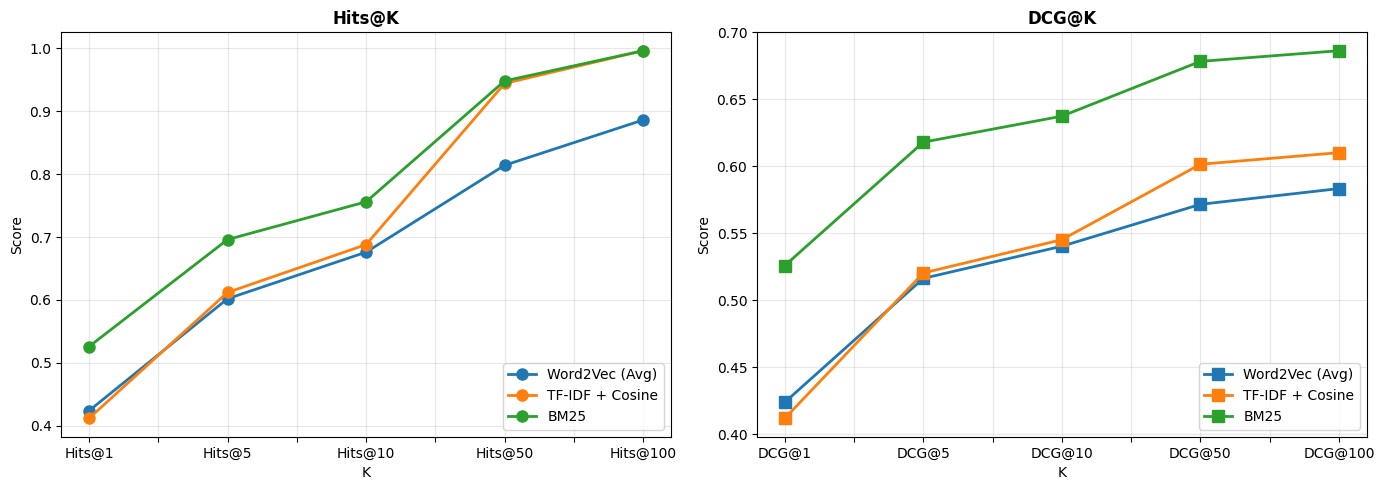

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hits_cols = [c for c in results_df.columns if 'Hits@' in c]
results_df[hits_cols].T.plot(ax=axes[0], marker='o', markersize=8, linewidth=2)
axes[0].set_title('Hits@K', fontsize=12, fontweight='bold')
axes[0].set_xlabel('K', fontsize=10)
axes[0].set_ylabel('Score', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='lower right')

dcg_cols = [c for c in results_df.columns if 'DCG@' in c]
results_df[dcg_cols].T.plot(ax=axes[1], marker='s', markersize=8, linewidth=2)
axes[1].set_title('DCG@K', fontsize=12, fontweight='bold')
axes[1].set_xlabel('K', fontsize=10)
axes[1].set_ylabel('Score', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

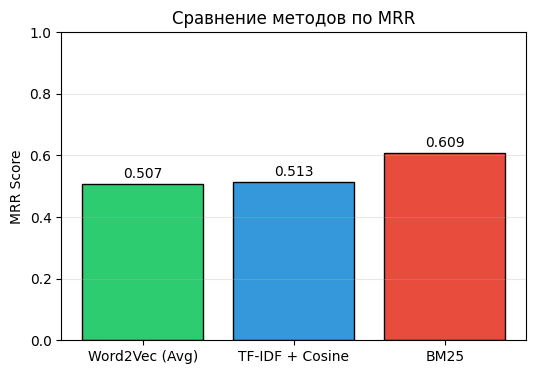

In [ ]:
plt.figure(figsize=(6, 4))
mrr_values = results_df['MRR']
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = plt.bar(mrr_values.index, mrr_values.values, color=colors, edgecolor='black')
plt.title('Сравнение методов по MRR', fontsize=12)
plt.ylabel('MRR Score', fontsize=10)
plt.ylim(0, 1)

for bar, value in zip(bars, mrr_values.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.show()

Видим, что лучший результат по всем метрикам показал BM25

In [ ]:
baseline_results = {
    'Word2Vec': w2v_results,
    'TF-IDF': tfidf_results,
    'BM25': bm25_results
}

In [ ]:
import pickle
with open('baseline_results.pkl', 'wb') as f:
    pickle.dump(baseline_results, f)

Теперь пробуем нейросетевые методы

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(device)

cuda


Дообучим BERT

In [ ]:
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation
from sentence_transformers import losses

In [ ]:
model_bert = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
from sklearn.metrics.pairwise import cosine_similarity
import random
import numpy as np
from tqdm.notebook import tqdm

Загружаем данные

In [ ]:
def read_corpus(filename):
    data = []
    with open(filename, encoding='utf-8') as file:
        for line in file:
            parts = line.strip().split('\t')
            data.append(parts)
    return data

In [ ]:
train_data = read_corpus('./data/train.tsv')
validation_data = read_corpus('./data/validation.tsv')

print(f"Train: {len(train_data)}")
print(f"Validation: {len(validation_data)}")

Train: 1000000
Validation: 3760


Создаём обучающие примеры

In [ ]:
train_examples = []
max_samples = 500000

for row in tqdm(train_data[:max_samples]):
    train_examples.append(InputExample(texts=[row[0], row[1]]))

  0%|          | 0/500000 [00:00<?, ?it/s]

Создаём правильный формат валидационных данных

In [ ]:
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator

dev_pairs = []
for row in validation_data[:1000]:
    dev_pairs.append((row[0], row[1], 1.0))

    negative = random.choice([r[0] for r in validation_data if r[0] != row[0]])
    dev_pairs.append((row[0], negative, 0.0))

evaluator = EmbeddingSimilarityEvaluator.from_input_examples(
    [InputExample(texts=[p[0], p[1]], label=p[2]) for p in dev_pairs],
    name='dev'
)

Создаём даталоадер и лосс

In [ ]:
train_dataloader = DataLoader(train_examples, batch_size=64, shuffle=True)
train_loss = losses.MultipleNegativesRankingLoss(model_bert)

Дообучение модели

In [ ]:
model_bert.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=3,
    warmup_steps=1000,
    optimizer_params={'lr': 2e-5},
    show_progress_bar=True,
    evaluator=evaluator,
    evaluation_steps=1000
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Dev Pearson Cosine,Dev Spearman Cosine
1000,0.830294,No log,0.856792,0.843604
2000,0.794457,No log,0.862394,0.847163
3000,0.784277,No log,0.864205,0.847631
4000,0.780046,No log,0.865754,0.848071
5000,0.754592,No log,0.867043,0.848258
6000,0.736679,No log,0.866159,0.847986
7000,0.742058,No log,0.867774,0.848154
7813,0.735399,No log,0.867799,0.848000
8000,0.726133,No log,0.867343,0.847901
9000,0.688809,No log,0.868274,0.849439


Полная оценка модели с обработкой рангов

In [ ]:
def evaluate_full(model, validation_data, max_samples=500):

    ranks = []

    for i, line in enumerate(tqdm(validation_data[:max_samples])):
        question = line[0]
        correct = line[1]
        candidates = line[1:]

        all_texts = [question] + candidates
        embeddings = model.encode(all_texts, convert_to_numpy=True)

        q_emb = embeddings[0:1]
        c_embs = embeddings[1:]

        similarities = cosine_similarity(q_emb, c_embs)[0]

        ranked_indices = np.argsort(similarities)[::-1]

        found_rank = None
        for rank, idx in enumerate(ranked_indices):
            if candidates[idx] == correct:
                found_rank = rank + 1
                break

        if found_rank:
            ranks.append(found_rank)
        else:
            ranks.append(len(candidates))

    hits_at_1 = sum(1 for r in ranks if r == 1) / len(ranks)
    hits_at_5 = sum(1 for r in ranks if r <= 5) / len(ranks)
    hits_at_10 = sum(1 for r in ranks if r <= 10) / len(ranks)
    mrr = np.mean([1/r for r in ranks])

    return {
        'MRR': mrr,
        'Hits@1': hits_at_1,
        'Hits@5': hits_at_5,
        'Hits@10': hits_at_10
    }

In [ ]:
results = evaluate_full(model_bert, validation_data, max_samples=500)



Полная оценка модели...


  0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

MRR: 0.7641
Hits@1: 0.6940
Hits@5: 0.8440
Hits@10: 0.8820


Построим графики для визуализации результатов

In [ ]:
baseline_results = {
    'Word2Vec (Avg)': {'MRR': 0.507},
    'TF-IDF': {'MRR': 0.51},
    'BM25': {'MRR': 0.60},
    'SBERT': {'MRR': results['MRR']}
}

Word2Vec (Avg)       - MRR: 0.5070
TF-IDF               - MRR: 0.5100
BM25                 - MRR: 0.6000
SBERT                - MRR: 0.7641


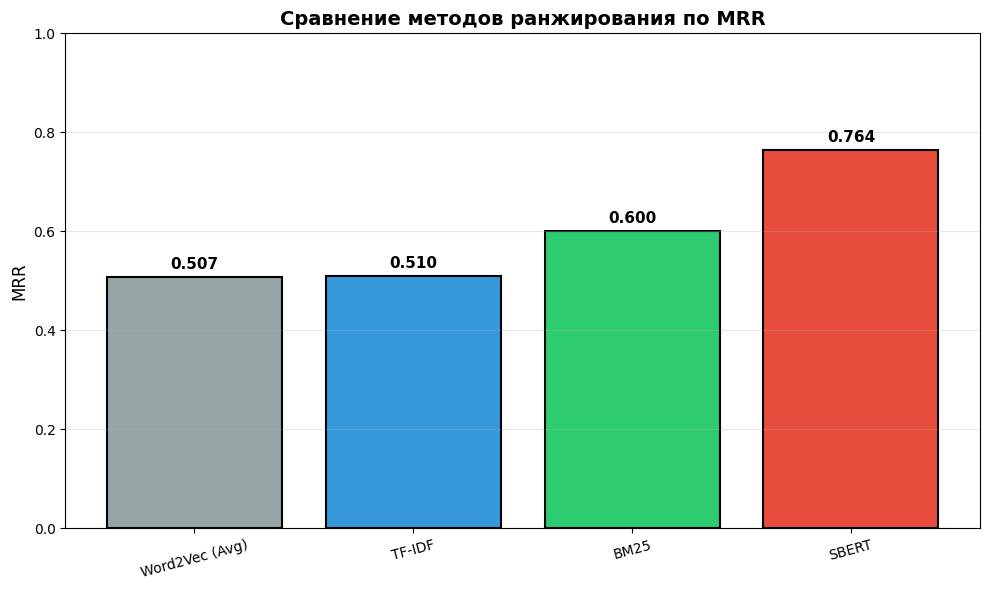

In [ ]:
for method, results in baseline_results.items():
    print(f"{method:20} - MRR: {results['MRR']:.4f}")

plt.figure(figsize=(10, 6))
methods = list(baseline_results.keys())
mrr_values = [baseline_results[m]['MRR'] for m in methods]
colors = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c']

bars = plt.bar(methods, mrr_values, color=colors, edgecolor='black', linewidth=1.5)
plt.title('Сравнение методов ранжирования по MRR', fontsize=14, fontweight='bold')
plt.ylabel('MRR', fontsize=12)
plt.ylim(0, 1)

for bar, value in zip(bars, mrr_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

В итоге дообученный SBERT дал самые лучшие результаты из исследуемых методов